In [8]:
import pandas as pd
import numpy as np
import re
import matplotlib.pyplot as plt
import torch
from tqdm import tqdm
from torch.nn.functional import pad
import os

In [9]:
os.chdir("/u/sebono/conversational_dominance/information_exchange_labelling")
print(os.getcwd())

from perplexity_labelling import compute_p1, compute_p2, compute_p3
from utils import (
    # VISUALIZATION
    rolling_kde_heatmap_with_turns,
    display_turns_colored_by_kde,
    compute_graph_perplexity,
    correlation_heatmap,
    # HELPERS
    compute_dominance_per_spk,
    expand_multiple_ppl_by_token,
    remove_match_prefix_ppl,
    assign_words_to_bins,
    compute_significance,
    display_colored_sentences
)

/u/sebono/conversational_dominance/information_exchange_labelling


In [10]:
from transformers import GPT2LMHeadModel, GPT2TokenizerFast
from transformers import LlamaForCausalLM, LlamaTokenizerFast

import argparse
import pickle
import os
import json
import pandas as pd

#model_id = "unsloth/Meta-Llama-3.1-8B-bnb-4bit"
model_id="gpt2-large"
device = "cuda:1"
perplexity_func = "p1"

if "gpt2" in model_id:
    model = GPT2LMHeadModel.from_pretrained(model_id).to(device)
    tokenizer = GPT2TokenizerFast.from_pretrained(model_id)
    start_of_sentence=" "
if "Llama" in model_id:
    model = LlamaForCausalLM.from_pretrained(model_id, device_map="auto")
    tokenizer = LlamaTokenizerFast.from_pretrained(model_id)
    start_of_sentence='<|begin_of_text|>'

In [11]:
import pandas as pd
import re
import numpy as np

multisimo_df_with_annotations = pd.read_csv("/u/sebono/conversational_dominance/data/processed/multisimo/transcript_dominance.csv")
multisimo_df_with_annotations

,file_name,speaker_1_1,speaker_1_2,speaker_1_3,speaker_1_4,speaker_1_5,speaker_2_1,speaker_2_2,speaker_2_3,speaker_2_4,speaker_2_5,speaker_1_dom_score,speaker_2_dom_score,file_content,speaker_1,speaker_2
0,S02,3.0,2.0,2.0,2.0,1.0,4.0,3.0,3.0,4.0,3.0,2.0,3.4,<MOD>: Ok so thanks for coming today. we're go...,P006,P007
1,S03,2.0,2.0,2.0,2.0,2.0,4.0,3.0,3.0,5.0,2.0,2.0,3.4,<MOD> Ok hello we are going to play a quiz. <...,P008,P009
2,S04,2.0,1.0,2.0,4.0,1.0,1.0,1.0,1.0,4.0,1.0,2.0,1.6,"<MOD>: ok Hello, thank you for coming today, w...",P010,P011
3,S05,4.0,4.0,4.0,4.0,3.0,3.0,2.0,3.0,1.0,1.0,3.8,2.0,"<MOD>: Ok hi welcome, thank you for coming tod...",P012,P013
4,S07,4.0,2.0,3.0,4.0,4.0,4.0,2.0,3.0,5.0,3.0,3.4,3.4,"<MOD>: <MOD>: Ok. So welcome, thank you very m...",P016,P017
5,S08,4.0,2.0,3.0,2.0,1.0,3.0,3.0,3.0,3.0,2.0,2.4,2.8,<MOD>: So good evening <SPK2>: Good evening. <...,P018,P019
6,S09,4.0,3.0,3.0,5.0,3.0,4.0,3.0,3.0,5.0,3.0,3.6,3.6,<MOD>: Ok <SPK2>: Yeah so <MOD>: So I would li...,P020,P021
7,S10,3.0,2.0,3.0,4.0,2.0,3.0,2.0,2.0,4.0,2.0,2.8,2.6,<MOD>: Ok. So I would like us to play a quiz. ...,P022,P023
8,S11,5.0,2.0,3.0,3.0,5.0,2.0,1.0,2.0,1.0,1.0,3.6,1.4,"<SPK1>: <MOD>: Right. So, I would like us to p...",P024,P025
9,S13,3.0,1.0,2.0,4.0,2.0,2.0,1.0,2.0,1.0,1.0,2.4,1.4,"<SPK1>: yeah <MOD>: Well hello, thanks very mu...",P028,P029


In [96]:
from glob import glob
import os, re, pickle
import numpy as np
import re
import pandas as pd
from tqdm import tqdm

BASE = "/u/sebono/conversational_dominance/notebooks/information_exchange_labelling/dataset_perplexity_results"


def _pair_distinguishable(spk_dict, alpha=0.05, adjust_p="fdr_bh"):
    """
    Returns True if <SPK1> and <SPK2> are statistically distinguishable
    by any test in compute_significance (after correction if requested).
    """
    # Only consider main speakers that are present
    spks = [s for s in spk_dict.keys() if s.startswith("<SPK")]
    if not ("<SPK1>" in spks and "<SPK2>" in spks):
        return False

    # Your function (must be in scope)
    results_list, results_dict = compute_significance(
        original_ppls_p_spk=spk_dict,
        spk_tokens=["<SPK1>", "<SPK2>"],
        alternative_mw="two-sided",
        equal_var_ttest=False,
        adjust_p=adjust_p
    )

    # Prefer adjusted p if present; otherwise raw p
    best_p = 1.0
    for row in results_list:
        if (row.get("spk_i"), row.get("spk_j")) in [("<SPK1>", "<SPK2>"), ("<SPK2>", "<SPK1>")]:
            p = row.get("p_value_adj", row.get("p_value"))
            if p is not None and not np.isnan(p):
                best_p = min(best_p, p)
    return best_p < alpha

def compute_dominance(dataset, model, ppls, base=BASE, agg=np.nanmean):
    out = {}
    rows = []

    for idx, name in enumerate(list(multisimo_df_with_annotations["file_name"])):
        el = multisimo_df_with_annotations[multisimo_df_with_annotations['file_name']==name]["file_content"]
        dialog = multisimo_df_with_annotations[multisimo_df_with_annotations['file_name']==name]["file_content"][list(el.keys())[0]]

        pattern = r'<(?:SPK[0-9]|MOD)>'
        dialog_lines = re.sub(r"[\[\(].*?[\]\)]", "", dialog).replace("<", "\n<").split("\n")[1:]
        matches = [f"{match}" for match in re.findall(pattern, f"{start_of_sentence}".join(dialog_lines))]
        token_list = [tokenizer(token, return_tensors="pt").input_ids[0] for token in dialog_lines]
        encodings = tokenizer(f"{start_of_sentence}".join(dialog_lines), return_tensors="pt")
        assert np.cumsum([len(token) for token in token_list])[-1] == encodings.input_ids[0].shape
        assert len(matches) == len(dialog_lines)

        all_data = pd.DataFrame({})
        for p_name in ['p1','p2','p3']:
            file_name_sample = f'/u/sebono/conversational_dominance/notebooks/information_exchange_labelling/dataset_perplexity_results/multisimo_{p_name}_{model}/dominance_scores_{name}.pkl'
            with open(file_name_sample, 'rb') as f:
                all_data[f"{p_name}"] = pickle.load(f)[name]

        filtered_tokens_p1, filtered_ppl_p1, filtered_encodings_p1, filtered_matches_p1 = remove_match_prefix_ppl(token_list, all_data['p1'], matches, tokenizer, min_len=3)
        assert np.cumsum([len(token) for token in filtered_tokens_p1])[-1], len(filtered_ppl)

        filtered_tokens_p2, filtered_ppl_p2, filtered_encodings_p2, filtered_matches_p2 = remove_match_prefix_ppl(token_list, all_data['p2'], matches, tokenizer, min_len=3)
        assert np.cumsum([len(token) for token in filtered_tokens_p2])[-1], len(filtered_ppl)

        filtered_tokens_p3, filtered_ppl_p3, filtered_encodings_p3, filtered_matches_p3 = remove_match_prefix_ppl(token_list, all_data['p3'], matches, tokenizer, min_len=3)
        assert np.cumsum([len(token) for token in filtered_tokens_p3])[-1], len(filtered_ppl)

        #assert len(filtered_tokens_p3) == len(token_list)
        assert len(filtered_tokens_p1) == len(filtered_tokens_p2)
        assert len(filtered_tokens_p1) == len(filtered_tokens_p3)
        assert filtered_encodings_p1 == filtered_encodings_p2
        assert filtered_encodings_p1 == filtered_encodings_p3
        filtered_encodings = filtered_encodings_p1

        all_data = pd.DataFrame({"p1":filtered_ppl_p1,"p2":filtered_ppl_p2, "p3":filtered_ppl_p3})
        all_data.bfill(inplace=True)

        baselined_ppls_p1_spk = compute_dominance_per_spk(filtered_ppl_p1, filtered_tokens_p1, filtered_matches_p1, tokenizer)
        baselined_ppls_p2_spk = compute_dominance_per_spk(filtered_ppl_p2, filtered_tokens_p2, filtered_matches_p2, tokenizer)
        baselined_ppls_p3_spk = compute_dominance_per_spk(filtered_ppl_p3, filtered_tokens_p3, filtered_matches_p3, tokenizer)

        out[name] = {}
        out[name]['p1'] = dict(zip(baselined_ppls_p1_spk.keys(), [np.mean(baselined_ppls_p1_spk[key]) for key in baselined_ppls_p1_spk.keys()]))
        out[name]['p2'] = dict(zip(baselined_ppls_p2_spk.keys(), [np.mean(baselined_ppls_p2_spk[key]) for key in baselined_ppls_p2_spk.keys()]))
        out[name]['p3'] = dict(zip(baselined_ppls_p3_spk.keys(), [np.mean(baselined_ppls_p3_spk[key]) for key in baselined_ppls_p3_spk.keys()]))

        # --- NEW: gate by significance; if not distinguishable, set SPK1/SPK2 to NaN for that ppl ---
        for p_name, spk_dict_full in [('p1', baselined_ppls_p1_spk),
                                      ('p2', baselined_ppls_p2_spk),
                                      ('p3', baselined_ppls_p3_spk)]:
            if not _pair_distinguishable(spk_dict_full, alpha=0.05, adjust_p="fdr_bh"):
                # Replace only SPK1/SPK2 with NaN (keep MOD or others as-is)
                if "<SPK1>" in out[name][p_name]:
                    out[name][p_name]["<SPK1>"] = np.nan
                if "<SPK2>" in out[name][p_name]:
                    out[name][p_name]["<SPK2>"] = np.nan

        # Collect tidy rows
        for ppl_key in ('p1','p2','p3'):
            for spk, val in out[name][ppl_key].items():
                rows.append((name, ppl_key, spk, float(val) if val is not None else np.nan))

    # build tidy rows as before
    df = pd.DataFrame(rows, columns=['file_name','ppl','speaker','mean_dominance'])

    # Pivot to columns = (speaker, ppl)
    wide = df.pivot_table(index='file_name',
                          columns=['speaker','ppl'],
                          values='mean_dominance',
                          aggfunc='mean')

    def spk_key(s):
        m = re.match(r'<SPK(\d+)>', s or '')
        return (1, int(m.group(1))) if m else (2, 0)

    spk_levels = list(wide.columns.levels[0])
    ppl_levels = list(wide.columns.levels[1])
    spk_levels = sorted(spk_levels, key=spk_key)
    desired_ppls = [p for p in ['p1','p2','p3'] if p in ppl_levels]

    wide = wide.reindex(pd.MultiIndex.from_product([spk_levels, desired_ppls]), axis=1)

    # Flatten (speaker, ppl) -> "<SPK#>_p#"
    wide.columns = [f"{spk}_{ppl}" for spk, ppl in wide.columns]
    wide = wide.reset_index()
    return wide, out

In [97]:
DATASET = "multisimo"      # e.g. "multisimo"
MODEL = model_id           # e.g. "gpt2-large"
PPLS = ["p1", "p2", "p3"]  # which folders to scan

data, out_data = compute_dominance(DATASET, MODEL, PPLS)

In [98]:
data

,file_name,<SPK1>_p1,<SPK1>_p2,<SPK1>_p3,<SPK2>_p1,<SPK2>_p2,<SPK2>_p3,<MOD>_p1,<MOD>_p2,<MOD>_p3
0,S02,NaN,NaN,3.204166,NaN,NaN,2.950220,3.673925,2.715827,2.902191
1,S03,3.614844,NaN,NaN,3.973222,NaN,NaN,3.531708,2.628982,3.061316
2,S04,NaN,1.904329,3.788779,NaN,2.100131,3.233173,3.214897,2.491752,3.252605
3,S05,3.833553,2.005451,2.988865,3.412965,2.161347,3.126620,3.314366,2.600927,2.985529
4,S07,3.694508,1.812375,NaN,3.336642,1.622964,NaN,3.666423,2.611721,2.928134
5,S08,NaN,NaN,3.569559,NaN,NaN,3.357007,3.809710,2.850759,2.929864
6,S09,NaN,1.845813,NaN,NaN,1.785329,NaN,3.366666,2.375487,2.919158
7,S10,NaN,1.995611,3.582191,NaN,1.919434,3.303069,3.299268,2.593326,3.573841
8,S11,3.855456,2.043912,NaN,3.361408,1.915491,NaN,3.382167,2.572804,2.834975
9,S13,3.480789,1.685946,3.404395,3.957331,2.065628,3.544259,3.482520,2.556800,2.952077


In [142]:
cols = ["file_name", "speaker_1_dom_score", "speaker_2_dom_score", 
        #"speaker_1_1", "speaker_1_2", "speaker_1_3", "speaker_1_4", "speaker_1_5", "speaker_2_1", "speaker_2_2", "speaker_2_3", "speaker_2_4", "speaker_2_5", 
        "<SPK1>_p1", "<SPK2>_p1", "<SPK1>_p2", "<SPK2>_p2", "<SPK1>_p3", "<SPK2>_p3"]
comparison_ppl_dom_data = data.merge(multisimo_df_with_annotations, on="file_name")[cols]
comparison_ppl_dom_data

,file_name,speaker_1_dom_score,speaker_2_dom_score,<SPK1>_p1,<SPK2>_p1,<SPK1>_p2,<SPK2>_p2,<SPK1>_p3,<SPK2>_p3
0,S02,2.0,3.4,NaN,NaN,NaN,NaN,3.204166,2.950220
1,S03,2.0,3.4,3.614844,3.973222,NaN,NaN,NaN,NaN
2,S04,2.0,1.6,NaN,NaN,1.904329,2.100131,3.788779,3.233173
3,S05,3.8,2.0,3.833553,3.412965,2.005451,2.161347,2.988865,3.126620
4,S07,3.4,3.4,3.694508,3.336642,1.812375,1.622964,NaN,NaN
5,S08,2.4,2.8,NaN,NaN,NaN,NaN,3.569559,3.357007
6,S09,3.6,3.6,NaN,NaN,1.845813,1.785329,NaN,NaN
7,S10,2.8,2.6,NaN,NaN,1.995611,1.919434,3.582191,3.303069
8,S11,3.6,1.4,3.855456,3.361408,2.043912,1.915491,NaN,NaN
9,S13,2.4,1.4,3.480789,3.957331,1.685946,2.065628,3.404395,3.544259


In [143]:
col_1 = ["speaker_1_dom_score", "speaker_2_dom_score"]
col_2 = ["<SPK1>_p1","<SPK2>_p1","<SPK1>_p2","<SPK2>_p2","<SPK1>_p3","<SPK2>_p3"]

In [144]:
corr, fig_corr, p, fig_p, fig_r = correlation_heatmap(col_1,col_2,comparison_ppl_dom_data)

In [145]:
fig_corr

In [141]:
fig_p

In [187]:
dialog[:500]

"<MOD>: Ok hi guys Thanks very much for coming <SPK1>: Hello <MOD>: here today <SPK2>: Thanks <MOD>: We're going to play a quiz. So I'm going to ask you three survey questions that were previously posed to a group of hundred people <SPK2>: hmm <MOD>: So for each question you have to give me the three most popular answers. You have to talk to each other, you need to work together and you will have to order these answers in terms of popularity. <SPK2>: ok <MOD>: Yeah? <SPK2>: Yeah. <MOD>: Is it cle"

In [142]:
import re 
pattern = r'<(?:SPK[0-9]|MOD)>'
dialog_lines = re.sub(r"[\[\(].*?[\]\)]", "", dialog).replace("<", "\n<").split("\n")[1:]
matches = [f"{match}" for match in re.findall(pattern, f"{start_of_sentence}".join(dialog_lines))]
token_list = [tokenizer(token, return_tensors="pt").input_ids[0] for token in dialog_lines]
encodings = tokenizer(f"{start_of_sentence}".join(dialog_lines), return_tensors="pt")
assert np.cumsum([len(token) for token in token_list])[-1] == encodings.input_ids[0].shape
assert len(matches) == len(dialog_lines)

In [143]:
#all_data = pd.DataFrame({})
#for p_name in ['p1','p2','p3']:
#    file_name_sample = f'/u/sebono/conversational_dominance/notebooks/information_exchange_labelling/dataset_perplexity_results/multisimo_{p_name}_{model_id}/dominance_scores_{file_name}.pkl'
#    with open(file_name_sample, 'rb') as f:
#        all_data[f"{p_name}"] = pickle.load(f)[file_name]

### Analysis

In [141]:
file_name="S18"
dialog = multisimo_df_with_annotations[multisimo_df_with_annotations['file_name']==file_name]["file_content"][12]

In [191]:
p1_mult = compute_p1(encodings, token_list, tokenizer, model, device, start_of_sentence=start_of_sentence, max_length = 1000, pattern=pattern, debug=False)
p2_mult = compute_p2(encodings, token_list, tokenizer, model, device, start_of_sentence=start_of_sentence, max_length = 1000, pattern=pattern, debug=False)
p3_mult = compute_p3(encodings, token_list, tokenizer, model, device, start_of_sentence=start_of_sentence, max_length = 1000, pattern=pattern, debug=False)

 79%|████████████████████████████████████████████████████████████████████████████████████████████████████████████▍                             | 3666/4666 [14:24<03:55,  4.24it/s]
/u/sebono/conversational_dominance/information_exchange_labelling/perplexity_labelling.py:129: UserWarning:

Creating a tensor from a list of numpy.ndarrays is extremely slow. Please consider converting the list to a single numpy.ndarray with numpy.array() before converting to a tensor. (Triggered internally at /pytorch/torch/csrc/utils/tensor_new.cpp:254.)

 79%|████████████████████████████████████████████████████████████████████████████████████████████████████████████▍                             | 3666/4666 [14:28<03:56,  4.22it/s]


In [192]:
all_data["p1"] = p1_mult
all_data["p2"] = p2_mult
all_data["p3"] = p3_mult

In [194]:
all_data.to_csv(f"/u/sebono/conversational_dominance/information_exchange_labelling/multisimo_{file_name}_{model_id}_1000.csv", index=False)

In [195]:
all_data.bfill(inplace=True)

filtered_tokens_p1, filtered_ppl_p1, filtered_encodings_p1, filtered_matches_p1 = remove_match_prefix_ppl(token_list, all_data['p1'], matches, tokenizer, min_len=10)
assert np.cumsum([len(token) for token in filtered_tokens_p1])[-1], len(filtered_ppl)

filtered_tokens_p2, filtered_ppl_p2, filtered_encodings_p2, filtered_matches_p2 = remove_match_prefix_ppl(token_list, all_data['p2'], matches, tokenizer, min_len=10)
assert np.cumsum([len(token) for token in filtered_tokens_p2])[-1], len(filtered_ppl)

filtered_tokens_p3, filtered_ppl_p3, filtered_encodings_p3, filtered_matches_p3 = remove_match_prefix_ppl(token_list, all_data['p3'], matches, tokenizer, min_len=10)
assert np.cumsum([len(token) for token in filtered_tokens_p3])[-1], len(filtered_ppl)

assert len(filtered_tokens_p1) == len(filtered_tokens_p2)
assert len(filtered_tokens_p1) == len(filtered_tokens_p3)
assert filtered_encodings_p1 == filtered_encodings_p2
assert filtered_encodings_p1 == filtered_encodings_p3
filtered_encodings = filtered_encodings_p1

all_data_filtered = pd.DataFrame({"p1":filtered_ppl_p1,"p2":filtered_ppl_p2, "p3":filtered_ppl_p3 })

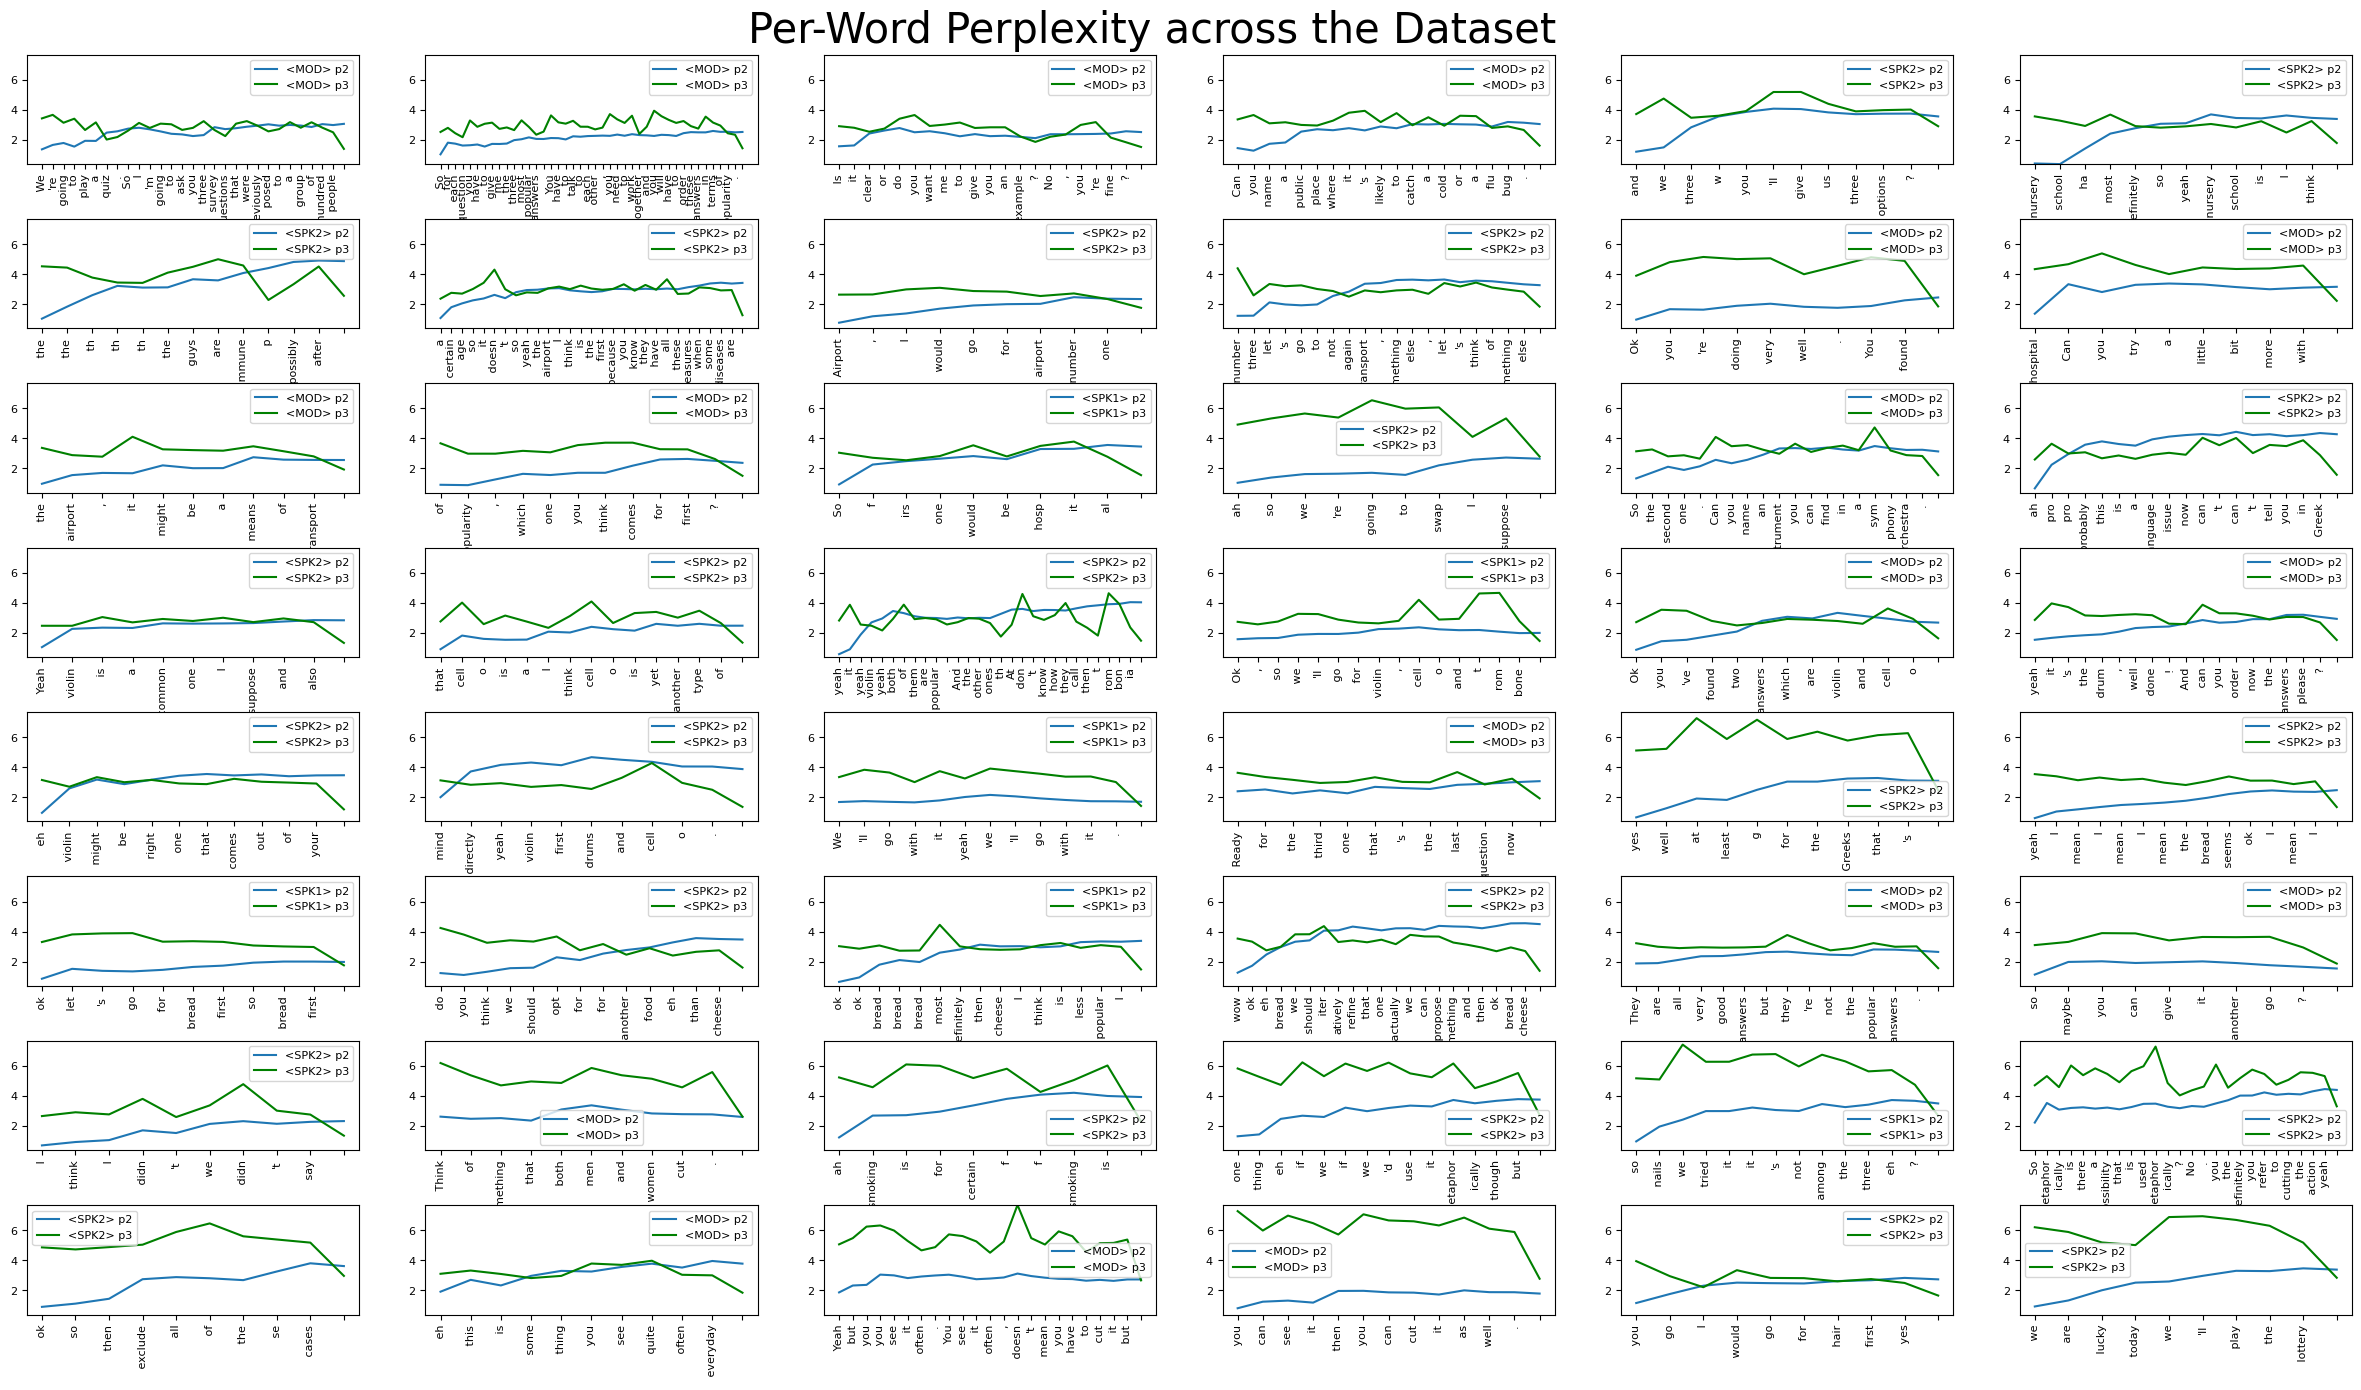

In [196]:
last=50
end = np.cumsum([len(l) for l in filtered_tokens_p1[:last]])[-1]
compute_graph_perplexity(tokenizer, filtered_tokens_p2[:last], filtered_ppl_p2[:end], filtered_ppl_p3[:end], filtered_matches_p2[:last], {"p1":"p2","p2":"p3"}, answers=None)

In [197]:
ppls_p1_spk = compute_dominance_per_spk(filtered_ppl_p1, filtered_tokens_p1, filtered_matches_p1, tokenizer)
ppls_p2_spk = compute_dominance_per_spk(filtered_ppl_p2, filtered_tokens_p2, filtered_matches_p2, tokenizer)
ppls_p3_spk = compute_dominance_per_spk(filtered_ppl_p3, filtered_tokens_p3, filtered_matches_p3, tokenizer)

In [207]:
np.mean(ppls_p2_spk["<SPK1>"])

2.2969187185168267

In [206]:
np.mean(ppls_p2_spk["<SPK2>"])

2.8844145680842947

In [200]:
np.mean(ppls_p3_spk['<SPK1>']), np.mean(ppls_p3_spk['<SPK2>'])

(3.5697378486394884, 3.6422839508671054)

In [201]:
np.mean(ppls_p1_spk['<SPK1>']) > np.mean(ppls_p1_spk['<SPK2>']), np.mean(ppls_p2_spk['<SPK1>']) > np.mean(ppls_p2_spk['<SPK2>']), np.mean(ppls_p3_spk['<SPK1>']) < np.mean(ppls_p3_spk['<SPK2>'])

(False, False, True)

In [202]:
rows, nested = compute_significance(ppls_p2_spk, ['<SPK1>', '<SPK2>'], adjust_p="fdr_bh")

# If you want a DataFrame:
import pandas as pd
df = pd.DataFrame(rows).sort_values(["test","p_value"])
df

,test,spk_i,spk_j,n_i,n_j,statistic,p_value,p_value_adj
0,KS,<SPK1>,<SPK2>,80,357,0.345098,1.945281e-07,1.945281e-07
1,Mann-Whitney U,<SPK1>,<SPK2>,80,357,9026.000000,2.668830e-07,2.668830e-07
2,T-test,<SPK1>,<SPK2>,80,357,-5.893040,2.465078e-08,2.465078e-08


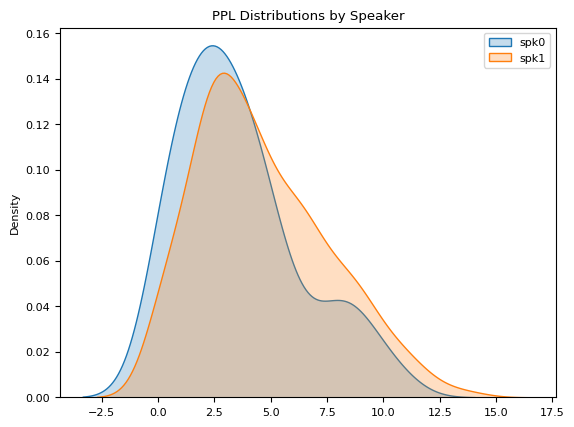

In [203]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.kdeplot(ppls_p1_spk[f"<SPK1>"], label="spk0", fill=True)
sns.kdeplot(ppls_p1_spk[f"<SPK2>"], label="spk1", fill=True)
plt.title("PPL Distributions by Speaker")
plt.legend()
plt.show()

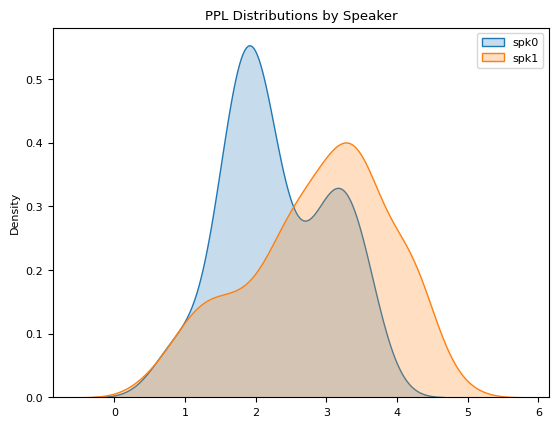

In [204]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.kdeplot(ppls_p2_spk[f"<SPK1>"], label="spk0", fill=True)
sns.kdeplot(ppls_p2_spk[f"<SPK2>"], label="spk1", fill=True)
plt.title("PPL Distributions by Speaker")
plt.legend()
plt.show()

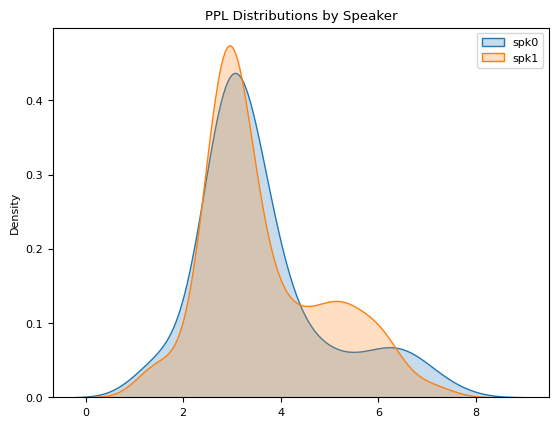

In [205]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.kdeplot(ppls_p3_spk[f"<SPK1>"], label="spk0", fill=True)
sns.kdeplot(ppls_p3_spk[f"<SPK2>"], label="spk1", fill=True)
plt.title("PPL Distributions by Speaker")
plt.legend()
plt.show()

In [208]:
# BEFORE
col_1 = ["p1","p2","p3"]
corr, fig_corr, p, fig_p, fig_r = correlation_heatmap(col_1,col_1,all_data_filtered)

In [209]:
fig_corr

In [210]:
fig_p

### Per-turn Analysis

In [211]:
per_turn_ppl = pd.DataFrame({"tokens": filtered_tokens_p1})

In [212]:
from itertools import count

# Start from offset
start_index = 0
counter = count(start=start_index)

# Function to assign token indices
def assign_indices(token_list):
    return [next(counter) for _ in token_list]

per_turn_ppl["ppl"] = per_turn_ppl["tokens"].apply(assign_indices)

In [213]:
per_turn_ppl["ppl"].iloc[-1][-1], len(filtered_ppl_p3)

(738, 739)

In [214]:
np.mean(filtered_ppl_p3[0:8])

2.954257994890213

In [216]:
per_turn_ppl["speaker"] = filtered_matches_p1

In [217]:
per_turn_ppl["p1"] = per_turn_ppl["ppl"].apply(
    lambda idxs: np.asarray(filtered_ppl_p1)[idxs].mean(axis=0) if len(idxs) > 0 else np.nan
)
per_turn_ppl["p2"] = per_turn_ppl["ppl"].apply(
    lambda idxs: np.asarray(filtered_ppl_p2)[idxs].mean(axis=0) if len(idxs) > 0 else np.nan
)
per_turn_ppl["p3"] = per_turn_ppl["ppl"].apply(
    lambda idxs: np.asarray(filtered_ppl_p3)[idxs].mean(axis=0) if len(idxs) > 0 else np.nan
)

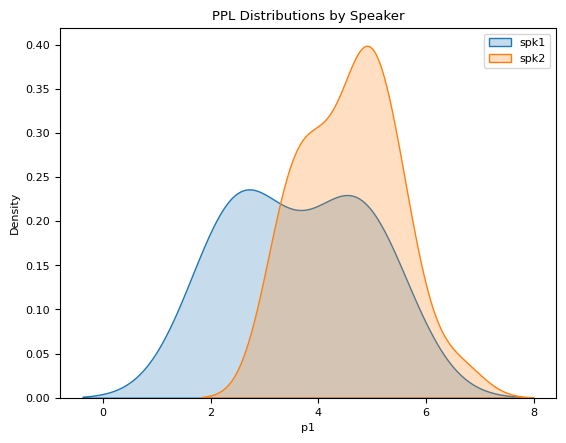

In [218]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.kdeplot(per_turn_ppl[per_turn_ppl["speaker"]=="<SPK1>"]['p1'], label="spk1", fill=True)
sns.kdeplot(per_turn_ppl[per_turn_ppl["speaker"]=="<SPK2>"]['p1'], label="spk2", fill=True)
plt.title("PPL Distributions by Speaker")
plt.legend()
plt.show()

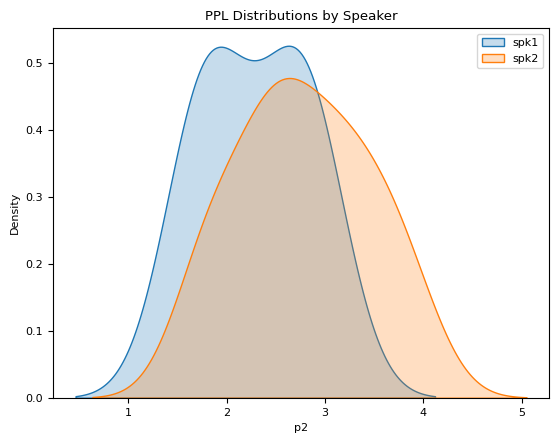

In [219]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.kdeplot(per_turn_ppl[per_turn_ppl["speaker"]=="<SPK1>"]['p2'], label="spk1", fill=True)
sns.kdeplot(per_turn_ppl[per_turn_ppl["speaker"]=="<SPK2>"]['p2'], label="spk2", fill=True)
plt.title("PPL Distributions by Speaker")
plt.legend()
plt.show()

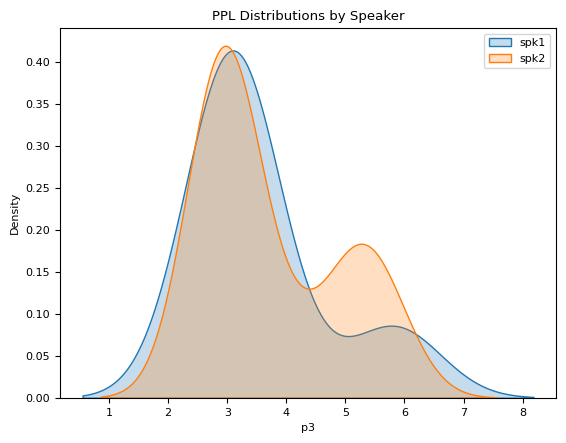

In [220]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.kdeplot(per_turn_ppl[per_turn_ppl["speaker"]=="<SPK1>"]['p3'], label="spk1", fill=True)
sns.kdeplot(per_turn_ppl[per_turn_ppl["speaker"]=="<SPK2>"]['p3'], label="spk2", fill=True)
plt.title("PPL Distributions by Speaker")
plt.legend()
plt.show()

In [221]:
ppls_p1_spk = dict({"<SPK1>": per_turn_ppl[per_turn_ppl["speaker"]=="<SPK1>"]['p1'], "<SPK2>": per_turn_ppl[per_turn_ppl["speaker"]=="<SPK2>"]['p1'], "<MOD>":per_turn_ppl[per_turn_ppl["speaker"]=="<MOD>"]['p1']})
ppls_p2_spk = dict({"<SPK1>": per_turn_ppl[per_turn_ppl["speaker"]=="<SPK1>"]['p2'], "<SPK2>": per_turn_ppl[per_turn_ppl["speaker"]=="<SPK2>"]['p2'], "<MOD>":per_turn_ppl[per_turn_ppl["speaker"]=="<MOD>"]['p2']})
ppls_p3_spk = dict({"<SPK1>": per_turn_ppl[per_turn_ppl["speaker"]=="<SPK1>"]['p3'], "<SPK2>": per_turn_ppl[per_turn_ppl["speaker"]=="<SPK2>"]['p3'], "<MOD>":per_turn_ppl[per_turn_ppl["speaker"]=="<MOD>"]['p3']})

In [222]:
rows, nested = compute_significance(ppls_p1_spk, list(np.unique(filtered_matches_p1)), adjust_p="fdr_bh")

# If you want a DataFrame:
import pandas as pd
df = pd.DataFrame(rows).sort_values(["test","p_value"])
df

,test,spk_i,spk_j,n_i,n_j,statistic,p_value,p_value_adj
1,KS,<MOD>,<SPK2>,18,24,0.680556,4.965996e-05,0.000149
2,KS,<SPK1>,<SPK2>,6,24,0.500000,1.486321e-01,0.222948
0,KS,<MOD>,<SPK1>,18,6,0.444444,3.023270e-01,0.302327
4,Mann-Whitney U,<MOD>,<SPK2>,18,24,41.000000,9.200105e-06,0.000028
5,Mann-Whitney U,<SPK1>,<SPK2>,6,24,39.000000,9.252663e-02,0.138790
3,Mann-Whitney U,<MOD>,<SPK1>,18,6,49.000000,7.702606e-01,0.770261
7,T-test,<MOD>,<SPK2>,18,24,-5.890118,6.748294e-07,0.000002
8,T-test,<SPK1>,<SPK2>,6,24,-1.767678,1.252095e-01,0.187814
6,T-test,<MOD>,<SPK1>,18,6,-0.813000,4.476553e-01,0.447655


In [223]:
rows, nested = compute_significance(ppls_p2_spk, list(np.unique(filtered_matches_p1)), adjust_p="fdr_bh")

# If you want a DataFrame:
import pandas as pd
df = pd.DataFrame(rows).sort_values(["test","p_value"])
df.head()

,test,spk_i,spk_j,n_i,n_j,statistic,p_value,p_value_adj
1,KS,<MOD>,<SPK2>,18,24,0.388889,0.069975,0.209924
2,KS,<SPK1>,<SPK2>,6,24,0.416667,0.329334,0.494000
0,KS,<MOD>,<SPK1>,18,6,0.277778,0.855702,0.855702
4,Mann-Whitney U,<MOD>,<SPK2>,18,24,145.000000,0.073156,0.219467
5,Mann-Whitney U,<SPK1>,<SPK2>,6,24,44.000000,0.157774,0.236660


In [224]:
rows, nested = compute_significance(ppls_p3_spk, list(np.unique(filtered_matches_p1)), adjust_p="fdr_bh")

# If you want a DataFrame:
import pandas as pd
df = pd.DataFrame(rows).sort_values(["test","p_value"])
df

,test,spk_i,spk_j,n_i,n_j,statistic,p_value,p_value_adj
1,KS,<MOD>,<SPK2>,18,24,0.263889,0.409622,0.973685
0,KS,<MOD>,<SPK1>,18,6,0.222222,0.969568,0.973685
2,KS,<SPK1>,<SPK2>,6,24,0.208333,0.973685,0.973685
4,Mann-Whitney U,<MOD>,<SPK2>,18,24,228.000000,0.770066,0.922539
5,Mann-Whitney U,<SPK1>,<SPK2>,6,24,77.000000,0.820237,0.922539
3,Mann-Whitney U,<MOD>,<SPK1>,18,6,56.000000,0.922539,0.922539
7,T-test,<MOD>,<SPK2>,18,24,-0.373057,0.711153,0.926569
8,T-test,<SPK1>,<SPK2>,6,24,-0.336281,0.745676,0.926569
6,T-test,<MOD>,<SPK1>,18,6,0.095144,0.926569,0.926569


In [225]:
per_turn_ppl["dialog"] = per_turn_ppl["tokens"].map(lambda x: " ".join([tokenizer.decode(token, skip_special_tokens=True) for token in x]))

In [227]:
# BEFORE
col_1 = ["p1","p2","p3"]
corr, fig_corr, p, fig_p, fig_r = correlation_heatmap(col_1,col_1,per_turn_ppl)

In [228]:
fig_corr